In [21]:
import pandas as pd
import re
import os
from pathlib import Path
import sys
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from seq_utils.peptide import switch_random_il, get_proforma_bracketed, has_il_outside_brackets

%matplotlib inline

In [22]:
# Load data and identify I/L swap pairs
df = pd.read_csv("../temp_data/input_file.txt", sep="\t")
df = df[df["Sequence"].str.len() < 30]

modification_dict_koina = {"(ox)": "UNIMOD:35", "(ac)": "UNIMOD:1", "(oxidation (m))": "UNIMOD:35", "(acetyl (protein n-term))": "UNIMOD:1"}
df["proforma_koina"] = df["Modified sequence"].apply(
    get_proforma_bracketed,
    before_aa=False, isalpha=True, isupper=True,
    pattern="\\([^()]*\\)|\\([^()]*\\([^()]*\\)[^()]*\\)",
    modification_dict=modification_dict_koina,
)

# Filter to unmodified, charge 2 (same as fragment intensity analysis)
df_intensity = df[~df["proforma_koina"].str.contains(r"\[", na=False)].copy()
df_intensity = df_intensity[~np.isnan(df_intensity["MS/MS scan number"])]
df_intensity = df_intensity[df_intensity["Charge"] == 2]

peptides = np.array(df_intensity["proforma_koina"])
peptides_switched = np.array([switch_random_il(p) for p in peptides])

# Unique pairs only
unique_pairs = {}
for orig, swap in zip(peptides, peptides_switched):
    if orig != swap and orig not in unique_pairs:
        unique_pairs[orig] = swap

print(f"Unique peptide pairs with I/L swap: {len(unique_pairs)}")

/tmp/ipykernel_3792487/4076744583.py:2: DtypeWarning: Columns (50) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../temp_data/input_file.txt", sep="\t")


Unique peptide pairs with I/L swap: 28823


In [23]:
# Load cached predictions
peptides_predictions = pd.read_csv("../temp_data/peptides_predictions_puyvelde.csv")
peptides_switch_predictions = pd.read_csv("../temp_data/peptides_switch_predictions_puyvelde.csv")

dict_predictions = dict(tuple(peptides_predictions.groupby("peptide_sequences")))
dict_predictions_switched = dict(tuple(peptides_switch_predictions.groupby("peptide_sequences")))
print(f"Loaded predictions for {len(dict_predictions)} original and {len(dict_predictions_switched)} swapped peptides")

Loaded predictions for 44226 original and 58907 swapped peptides


In [24]:
# Compute per-ion intensity differences with distance from swap site
#
# Distance definition (unified for b and y ions):
#   distance >= 1: ion contains the swap site
#   distance <= 0: ion does NOT contain the swap site
#   distance = 1:  swap is right at the cleavage boundary (most directly affected)
#
# For b_n (covers residues 0..n-1):  distance = n - swap_pos
# For y_m (covers residues L-m..L-1): distance = m + swap_pos - L + 1

results = []
for orig_seq, swap_seq in tqdm(unique_pairs.items()):
    clean_orig = re.sub(r'\[.*?\]', '', orig_seq)
    clean_swap = re.sub(r'\[.*?\]', '', swap_seq)
    if len(clean_orig) != len(clean_swap):
        continue

    # Find swap position
    swap_pos = None
    for i, (a, b) in enumerate(zip(clean_orig, clean_swap)):
        if a != b:
            swap_pos = i
            break
    if swap_pos is None:
        continue

    seq_len = len(clean_orig)
    swap_aa = clean_orig[swap_pos]
    left_aa = clean_orig[swap_pos - 1] if swap_pos > 0 else None
    right_aa = clean_orig[swap_pos + 1] if swap_pos < seq_len - 1 else None

    # Get predictions
    pred_orig = dict_predictions.get(orig_seq)
    pred_swap = dict_predictions_switched.get(swap_seq)
    if pred_orig is None or pred_swap is None:
        continue

    # Merge on annotation to compare ion-by-ion
    df_o = pred_orig[["annotation", "intensities"]].copy()
    df_s = pred_swap[["annotation", "intensities"]].copy()
    merged = pd.merge(df_o, df_s, on="annotation", suffixes=("_orig", "_swap"))

    # Normalize intensities per peptide (max = 1)
    max_int = max(merged["intensities_orig"].max(), merged["intensities_swap"].max())
    if max_int == 0:
        continue

    for _, row in merged.iterrows():
        match = re.match(r"([by])(\d+)\+(\d+)", row["annotation"])
        if not match:
            continue

        ion_type = match.group(1)
        ion_num = int(match.group(2))
        ion_charge = int(match.group(3))

        # Unified distance: positive = contains swap, negative = doesn't
        if ion_type == "b":
            distance = ion_num - swap_pos
        else:  # y
            distance = ion_num + swap_pos - seq_len + 1

        contains_swap = distance >= 1
        norm_orig = row["intensities_orig"] / max_int
        norm_swap = row["intensities_swap"] / max_int
        abs_diff = abs(norm_orig - norm_swap)

        results.append({
            "peptide": orig_seq,
            "ion_type": ion_type,
            "ion_num": ion_num,
            "ion_charge": ion_charge,
            "swap_pos": swap_pos,
            "seq_len": seq_len,
            "distance": distance,
            "contains_swap": contains_swap,
            "intensity_orig": norm_orig,
            "intensity_swap": norm_swap,
            "abs_diff": abs_diff,
            "swap_aa": swap_aa,
            "left_aa": left_aa,
            "right_aa": right_aa,
        })

diff_df = pd.DataFrame(results)
print(f"Total ion comparisons: {len(diff_df)}")
print(f"Contains swap: {diff_df['contains_swap'].sum()} ({diff_df['contains_swap'].mean()*100:.1f}%)")
print(f"Does not contain swap: {(~diff_df['contains_swap']).sum()} ({(~diff_df['contains_swap']).mean()*100:.1f}%)")

100%|██████████| 28823/28823 [05:34<00:00, 86.28it/s] 


Total ion comparisons: 17586034
Contains swap: 9100955 (51.8%)
Does not contain swap: 8485079 (48.2%)


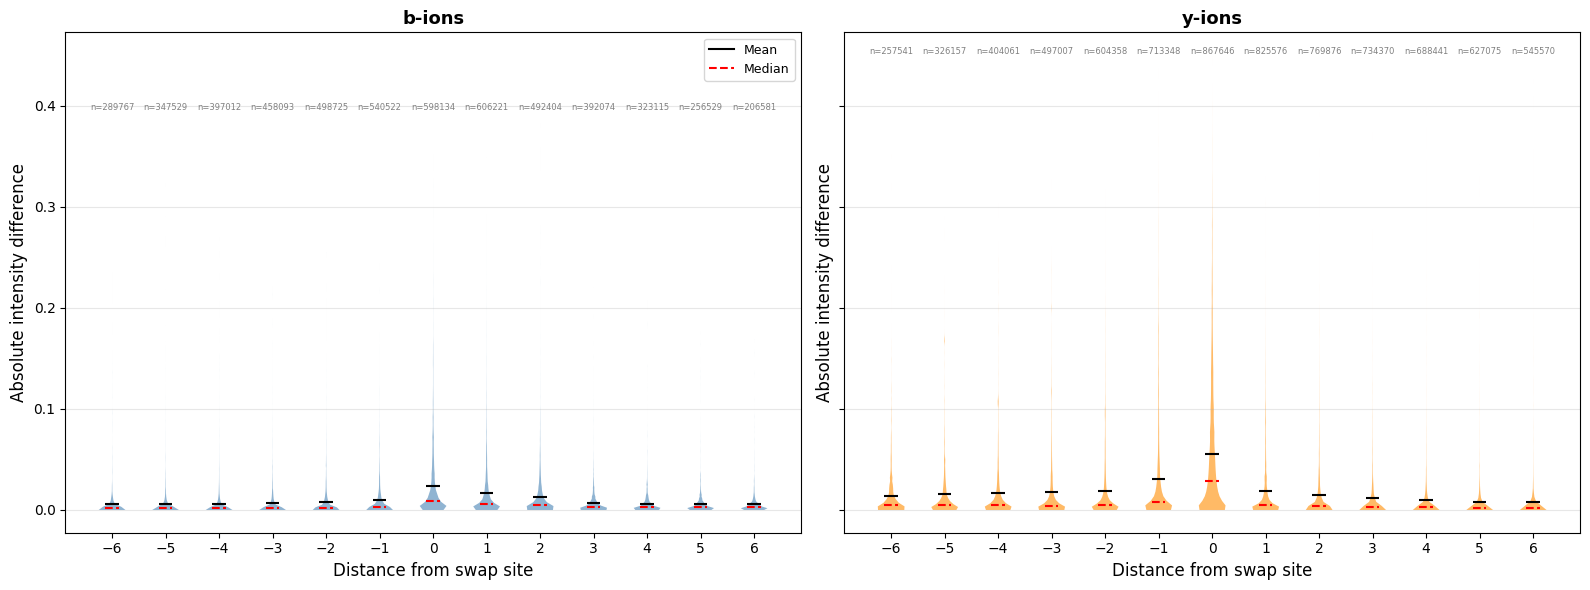

In [25]:
# Intensity difference distribution vs distance from swap site, split by ion type
plot_df = diff_df[(diff_df["distance"] >= -6) & (diff_df["distance"] <= 6)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, (ion_type, color) in zip(axes, [("b", "steelblue"), ("y", "darkorange")]):
    sub = plot_df[plot_df["ion_type"] == ion_type]
    parts = ax.violinplot(
        [sub.loc[sub["distance"] == d, "abs_diff"].values for d in range(-6, 7)],
        positions=range(-6, 7),
        showmeans=True,
        showmedians=True,
        showextrema=False,
    )
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
    parts["cmeans"].set_color("black")
    parts["cmedians"].set_color("red")
    parts["cmedians"].set_linestyle("--")

    ax.set_xlabel("Distance from swap site", fontsize=12)
    ax.set_ylabel("Absolute intensity difference", fontsize=12)
    ax.set_title(f"{ion_type}-ions", fontsize=13, fontweight="bold")
    ax.set_xticks(range(-6, 7))
    ax.grid(True, alpha=0.3, axis="y")

    # Add sample counts
    for d in range(-6, 7):
        n = (sub["distance"] == d).sum()
        if n > 0:
            ax.text(d, ax.get_ylim()[1] * 0.97, f"n={n}", ha="center", va="top", fontsize=6, color="gray")

from matplotlib.lines import Line2D
axes[0].legend(
    handles=[
        Line2D([0], [0], color="black", linewidth=1.5, label="Mean"),
        Line2D([0], [0], color="red", linewidth=1.5, linestyle="--", label="Median"),
    ],
    loc="upper right", fontsize=9,
)

plt.tight_layout()
plt.savefig("../temp_data/figure6a_intensity_diff_by_distance.png", dpi=300, bbox_inches='tight')
plt.show()

In [26]:
# Quantify: how far does the effect extend beyond the direct flanking ions?
# Compare ions at distance 1 (direct) vs distance 2, 3, ... (extended)
# Also check if ions that should NOT be affected (distance <= 0) show any change

contains = diff_df[diff_df["contains_swap"]]
not_contains = diff_df[~diff_df["contains_swap"]]

print("Intensity difference summary:")
print(f"  Ions containing swap site:     mean={contains['abs_diff'].mean():.6f}, median={contains['abs_diff'].median():.6f}, n={len(contains)}")
print(f"  Ions NOT containing swap site: mean={not_contains['abs_diff'].mean():.6f}, median={not_contains['abs_diff'].median():.6f}, n={len(not_contains)}")
print()

# By specific distance
print("By distance from swap:")
for d in range(-3, 8):
    sub = diff_df[diff_df["distance"] == d]
    if len(sub) > 0:
        pct_nonzero = (sub["abs_diff"] > 1e-6).mean() * 100
        print(f"  distance={d:+2d}: mean={sub['abs_diff'].mean():.6f}  %non-zero={pct_nonzero:.1f}%  n={len(sub)}")

Intensity difference summary:
  Ions containing swap site:     mean=0.010161, median=0.002691, n=9100955
  Ions NOT containing swap site: mean=0.017953, median=0.003746, n=8485079

By distance from swap:
  distance=-3: mean=0.012606  %non-zero=97.7%  n=955100
  distance=-2: mean=0.014025  %non-zero=98.0%  n=1103083
  distance=-1: mean=0.021744  %non-zero=97.0%  n=1253870
  distance=+0: mean=0.042494  %non-zero=93.6%  n=1465780
  distance=+1: mean=0.018192  %non-zero=98.6%  n=1431797
  distance=+2: mean=0.013774  %non-zero=96.3%  n=1262280
  distance=+3: mean=0.010121  %non-zero=94.8%  n=1126444
  distance=+4: mean=0.008713  %non-zero=94.7%  n=1011556
  distance=+5: mean=0.007583  %non-zero=94.4%  n=883604
  distance=+6: mean=0.007444  %non-zero=93.3%  n=752151
  distance=+7: mean=0.007004  %non-zero=94.1%  n=653714


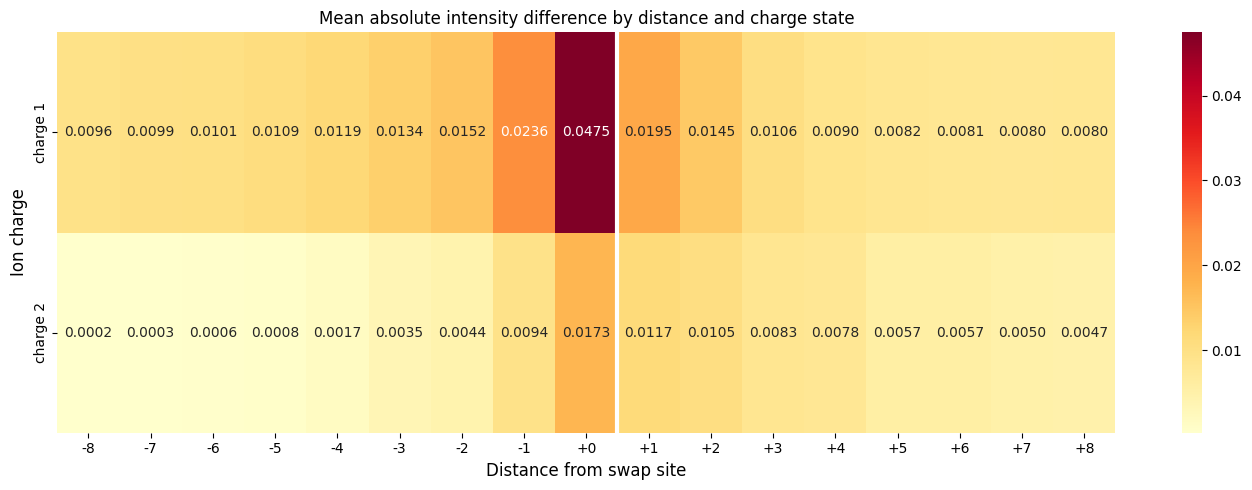

In [27]:
# Heatmap: intensity difference by (distance, charge)
fig, ax = plt.subplots(figsize=(14, 5))

# Pivot: distance x charge
pivot_data = diff_df[(diff_df["distance"] >= -8) & (diff_df["distance"] <= 8)].copy()
pivot = pivot_data.groupby(["distance", "ion_charge"])["abs_diff"].mean().unstack(fill_value=0)

sns.heatmap(pivot.T, cmap="YlOrRd", annot=True, fmt=".4f", ax=ax,
            xticklabels=[f"{int(d):+d}" for d in pivot.index],
            yticklabels=[f"charge {int(c)}" for c in pivot.columns])
ax.set_xlabel("Distance from swap site", fontsize=12)
ax.set_ylabel("Ion charge", fontsize=12)
ax.set_title("Mean absolute intensity difference by distance and charge state", fontsize=12)
ax.axvline(x=list(pivot.index).index(1) if 1 in pivot.index else 0, color="white", linewidth=3)

plt.tight_layout()
plt.savefig("../temp_data/figure6b_heatmap_distance_charge.png", dpi=300, bbox_inches='tight')
plt.show()

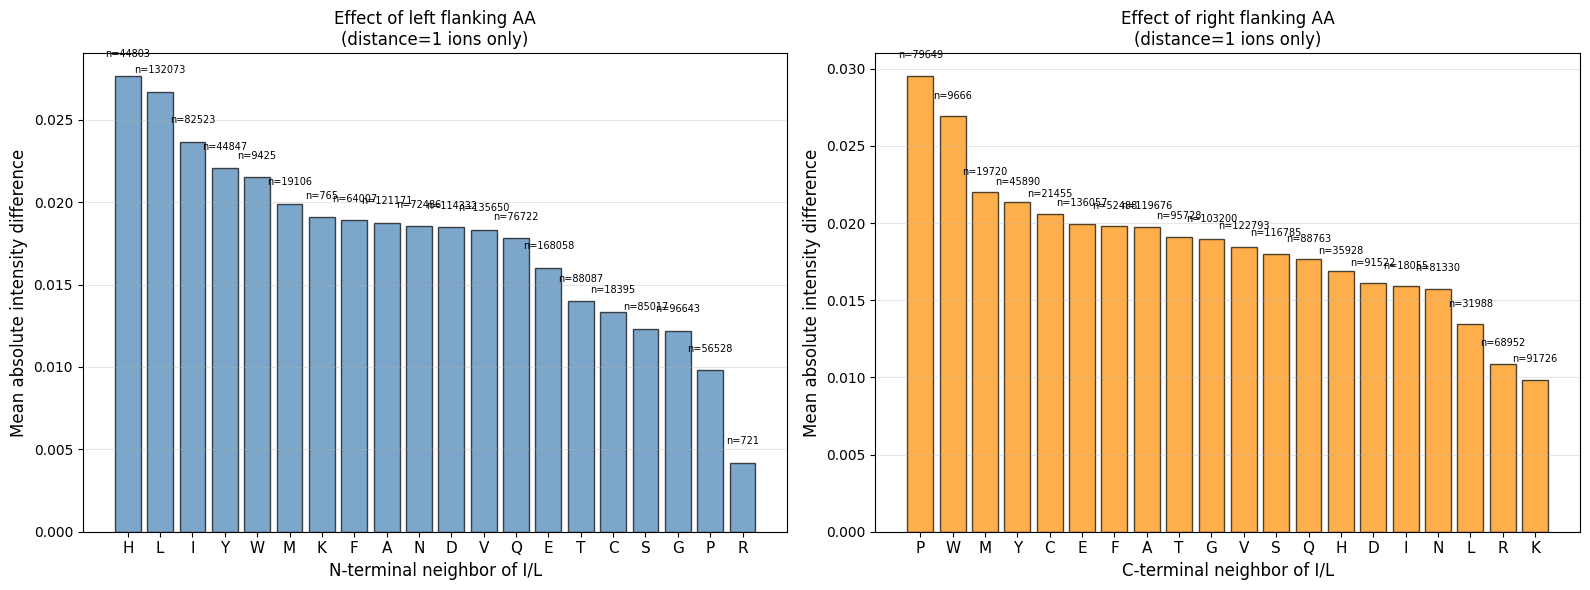

In [28]:
# Effect of flanking amino acids on intensity difference
# Only look at ions at distance=1 (most directly affected by the swap)
direct_ions = diff_df[diff_df["distance"] == 1].copy()

amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left flanking AA (N-terminal neighbor)
ax1 = axes[0]
left_means = []
for aa in amino_acids:
    sub = direct_ions[direct_ions["left_aa"] == aa]
    if len(sub) >= 10:
        left_means.append({"aa": aa, "mean_diff": sub["abs_diff"].mean(), "count": len(sub)})
left_df = pd.DataFrame(left_means).sort_values("mean_diff", ascending=False)

if len(left_df) > 0:
    bars = ax1.bar(range(len(left_df)), left_df["mean_diff"], color="steelblue", edgecolor="black", alpha=0.7)
    ax1.set_xticks(range(len(left_df)))
    ax1.set_xticklabels(left_df["aa"], fontsize=11)
    for bar, count in zip(bars, left_df["count"]):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'n={count}', ha='center', va='bottom', fontsize=7)
ax1.set_xlabel("N-terminal neighbor of I/L", fontsize=12)
ax1.set_ylabel("Mean absolute intensity difference", fontsize=12)
ax1.set_title("Effect of left flanking AA\n(distance=1 ions only)", fontsize=12)
ax1.grid(True, alpha=0.3, axis="y")

# Right flanking AA (C-terminal neighbor)
ax2 = axes[1]
right_means = []
for aa in amino_acids:
    sub = direct_ions[direct_ions["right_aa"] == aa]
    if len(sub) >= 10:
        right_means.append({"aa": aa, "mean_diff": sub["abs_diff"].mean(), "count": len(sub)})
right_df = pd.DataFrame(right_means).sort_values("mean_diff", ascending=False)

if len(right_df) > 0:
    bars = ax2.bar(range(len(right_df)), right_df["mean_diff"], color="darkorange", edgecolor="black", alpha=0.7)
    ax2.set_xticks(range(len(right_df)))
    ax2.set_xticklabels(right_df["aa"], fontsize=11)
    for bar, count in zip(bars, right_df["count"]):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'n={count}', ha='center', va='bottom', fontsize=7)
ax2.set_xlabel("C-terminal neighbor of I/L", fontsize=12)
ax2.set_ylabel("Mean absolute intensity difference", fontsize=12)
ax2.set_title("Effect of right flanking AA\n(distance=1 ions only)", fontsize=12)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("../temp_data/figure6c_flanking_aa_effect.png", dpi=300, bbox_inches='tight')
plt.show()

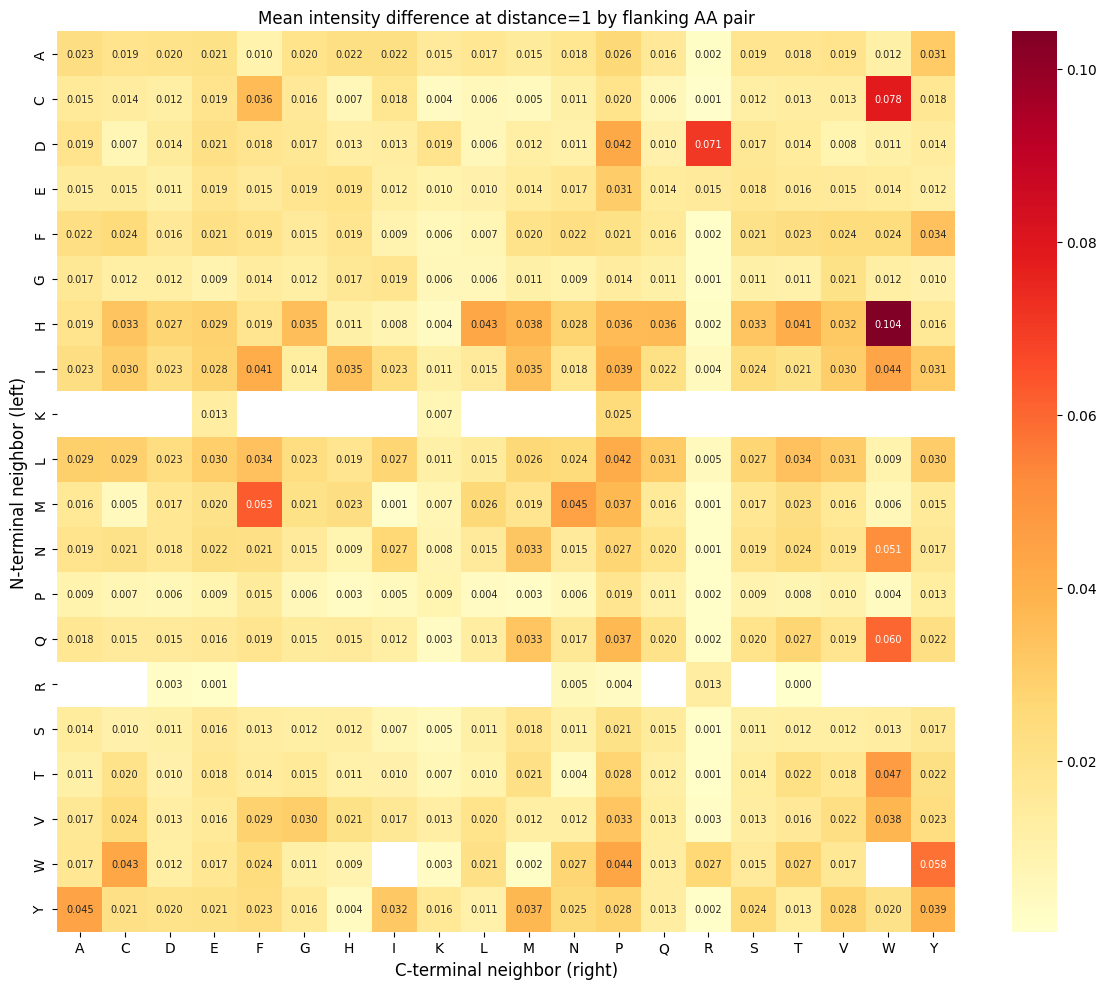

In [29]:
# Heatmap: mean intensity difference by flanking AA pair (left x right)
# at distance=1 (direct flanking ions)
direct_ions = diff_df[diff_df["distance"] == 1].copy()
direct_ions = direct_ions.dropna(subset=["left_aa", "right_aa"])

amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

heatmap = np.full((len(amino_acids), len(amino_acids)), np.nan)
counts = np.zeros((len(amino_acids), len(amino_acids)))
for i, left in enumerate(amino_acids):
    for j, right in enumerate(amino_acids):
        sub = direct_ions[(direct_ions["left_aa"] == left) & (direct_ions["right_aa"] == right)]
        if len(sub) >= 5:
            heatmap[i, j] = sub["abs_diff"].mean()
            counts[i, j] = len(sub)

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.isnan(heatmap)
sns.heatmap(heatmap, mask=mask, cmap="YlOrRd", ax=ax, annot=True, fmt=".3f",
            xticklabels=amino_acids, yticklabels=amino_acids, annot_kws={"fontsize": 7})
ax.set_xlabel("C-terminal neighbor (right)", fontsize=12)
ax.set_ylabel("N-terminal neighbor (left)", fontsize=12)
ax.set_title("Mean intensity difference at distance=1 by flanking AA pair", fontsize=12)

plt.tight_layout()
plt.savefig("../temp_data/figure6d_flanking_pair_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# Extended effect analysis: are ions beyond distance 1-2 still affected?
# Compare the intensity difference at each distance to a baseline (distance <= -3)
baseline = diff_df[diff_df["distance"] <= -3]["abs_diff"].mean()
baseline_std = diff_df[diff_df["distance"] <= -3]["abs_diff"].std()

print(f"Baseline (distance <= -3): mean={baseline:.6f}, std={baseline_std:.6f}")
print()

print("Distance  Mean diff    Ratio to baseline  Significantly above baseline?")
print("-" * 70)
for d in range(-5, 11):
    sub = diff_df[diff_df["distance"] == d]
    if len(sub) < 10:
        continue
    mean_d = sub["abs_diff"].mean()
    ratio = mean_d / baseline if baseline > 0 else 0
    # Simple z-test against baseline
    se = sub["abs_diff"].std() / np.sqrt(len(sub))
    z = (mean_d - baseline) / se if se > 0 else 0
    sig = "***" if z > 3.29 else "**" if z > 2.58 else "*" if z > 1.96 else ""
    print(f"  {d:+3d}      {mean_d:.6f}     {ratio:6.2f}x            {sig:3s}  (n={len(sub)})")

Baseline (distance <= -3): mean=0.010147, std=0.023585

Distance  Mean diff    Ratio to baseline  Significantly above baseline?
----------------------------------------------------------------------
   -5      0.010421       1.03x            ***  (n=673686)
   -4      0.011280       1.11x            ***  (n=801073)
   -3      0.012606       1.24x            ***  (n=955100)
   -2      0.014025       1.38x            ***  (n=1103083)
   -1      0.021744       2.14x            ***  (n=1253870)
   +0      0.042494       4.19x            ***  (n=1465780)
   +1      0.018192       1.79x            ***  (n=1431797)
   +2      0.013774       1.36x            ***  (n=1262280)
   +3      0.010121       1.00x                 (n=1126444)
   +4      0.008713       0.86x                 (n=1011556)
   +5      0.007583       0.75x                 (n=883604)
   +6      0.007444       0.73x                 (n=752151)
   +7      0.007004       0.69x                 (n=653714)
   +8      0.006891       0